## What is the problem?

Player have a boundary of gold. A **collector** costs 100 (gold), one **warrior** costs 200 (gold). *I want to maximize my production utility.*

The first step is formulate the problem mathematically.

- $x_c = collector$
- $x_w = warrior$
- $C_u$ = $current$ $units$
- $b$ = $boundary$

The second step is define the constraints.
- We know each cost in terms of gold for each unit, however we have a boundary in the gold, 
- Each variable needs to be positive. (The constraint of consider only integers values is a complex problem
so isn't considered for this project)
- The maximun number of existing units for each player must be less or equal to **50** considering the current units on the game.

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq b$

3. $x_c + x_w \leq 50 - C_u$

We plot the region delimited by the constraint. In this region we have all possible solutions to fulfill the constraint, however we don't know which is the better solution for our problem, we cover these problem in the next step.

In [201]:
import matplotlib.pyplot as plt
import numpy as np

# CONSTANTS for the cost of each existent unit on the game
COST_COLLECTORS = 100
COST_WARRIORS  = 200
MAXIMUM_NUMBER_UNITS = 50
CURRENT_UNITS = 10

# DEFINE the boundary of available gold
BOUNDARY = 6000

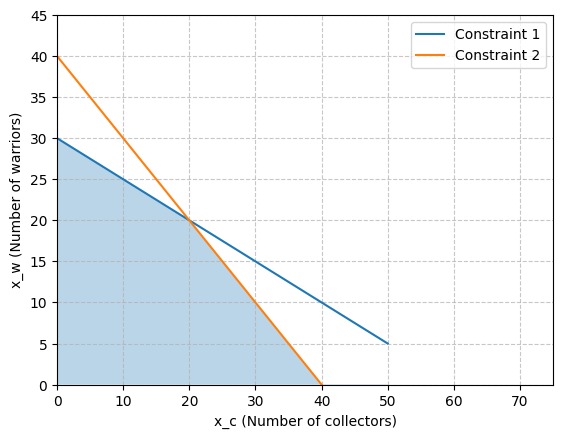

In [202]:
def plot_solution_space(optimal_point=True,x_coord=0,y_coord=0):
    # DEFINE the solution space knowing for the function
    y1 = lambda x: (BOUNDARY - COST_COLLECTORS * x) / COST_WARRIORS
    y2 = lambda x: (MAXIMUM_NUMBER_UNITS - x - CURRENT_UNITS) 

    # COMPUTE how much collectors (x-axis) which could be purchased
    LIMIT = min(BOUNDARY / COST_COLLECTORS, MAXIMUM_NUMBER_UNITS)

    """
    DEFINE the x-axis where the left-limit is zero, 
    and the rigth-limit is the maximum number of collectors which could be purchased with the boundary 
    """
    x = np.linspace(0, LIMIT,100)

    # COMPUTE the values of y taking points of x
    val_y1 = y1(x)
    val_y2 = y2(x)

    # PLOTING the solution taking X and Y
    plt.plot(x,val_y1, label='Constraint 1')
    plt.plot(x,val_y2, label="Constraint 2")

    if optimal_point == True:
        plt.scatter(x_coord,y_coord, color='red', zorder=5, label='optimal point')

    y_intersection = np.minimum(val_y1,val_y2)
    # Fill the space in the space of X and two curves in Y y=0 and y=function defined previously
    plt.fill_between(x, 0, y_intersection, alpha=0.3)

    plt.xlim(0, max(x) * 1.5)
    plt.ylim(0, max(val_y1) * 1.5)
    plt.xlabel('x_c (Number of collectors)')
    plt.ylabel('x_w (Number of warriors)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_solution_space(False)

We want to maximize the utility knowing the cost in terms of gold of each unit and the solution space. However we have to define how much important is to have collectors or warriors, and that definition is given by weigths.

$max($ $\theta_{1} * x_c + \theta_{2} * x_w )$

subject to:

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq b$

3. $x_c + x_w \leq 50 - C_u$

where:
- $\theta_{1}:$ The importance of having collectors on this state.
- $\theta_{2}:$ The importance of having warriors on this state.

Now with the problem statement we can search a good solution for the problem considering the constraints. We formulate the function to apply with different weigths.

In [203]:
from scipy.optimize import linprog
def linear_programming_solutions(coef, A_ub, b_ub, bounds):
    results = linprog(coef, A_ub=A_ub, b_ub=b_ub, bounds=bounds)
    return results.x[0], results.x[1]

#### First scenario we consider that have collectors is more important than have warriors.

You have to produce 40.0 collectors and 0.0 warriors.


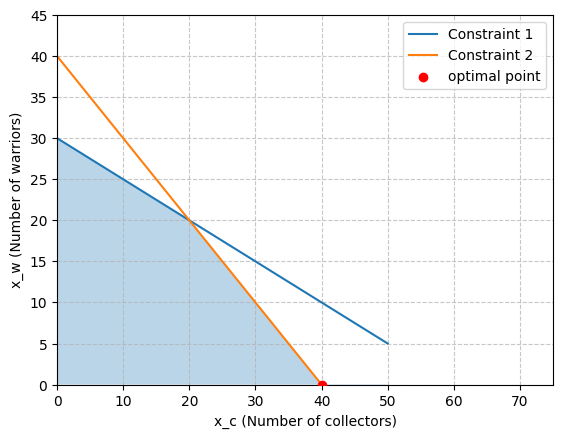

In [204]:
# Coeficients (weigths) of the objective function (denied for maximization)
first_scenario_coeficients = [-1,0]

# Constraint 1: cost_a * xc + cost_b * xw <= budget
# Constraint 2: xc + xw <= 50
A_matrix_constraints = [
    [COST_COLLECTORS, COST_WARRIORS],
    [1,1]
]
b_matrix_boudary = [
    BOUNDARY,
    MAXIMUM_NUMBER_UNITS - CURRENT_UNITS
]

# Bounds for the variables 
bounds = [(0,None), (0,None)]

first_n_collectors, first_n_warriors = linear_programming_solutions(first_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {first_n_collectors} collectors and {first_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=first_n_collectors,y_coord=first_n_warriors)

#### Second scenario we consider that have warriors is more important than have collectors.

You have to produce 0.0 collectors and 30.0 warriors.


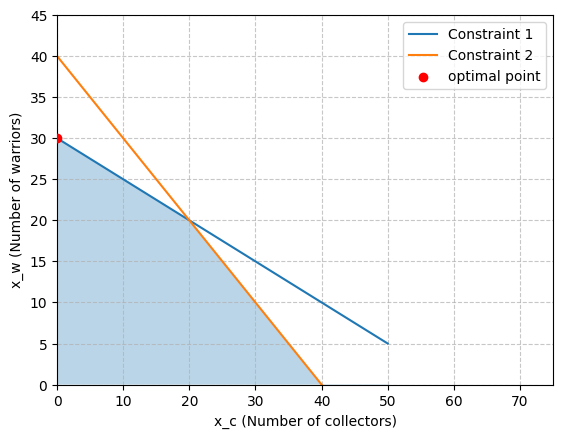

In [205]:
# Coeficients (weigths) of the objective function (denied for maximization)
second_scenario_coeficients = [0,-1]

second_n_collectors, second_n_warriors = linear_programming_solutions(second_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {second_n_collectors} collectors and {second_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=second_n_collectors,y_coord=second_n_warriors)

#### Third scenario we consider that have warriors is equal of important than have collectors.

You have to produce 20.0 collectors and 20.0 warriors.


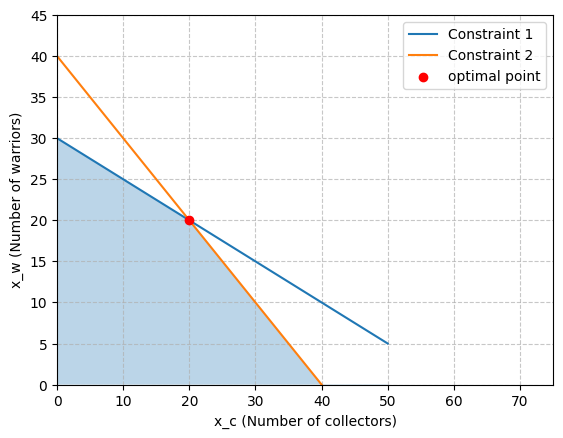

In [206]:
# Coeficients (weigths) of the objective function (denied for maximization)
third_scenario_coeficients = [-1,-1]

third_n_collectors, third_n_warriors = linear_programming_solutions(third_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {third_n_collectors} collectors and {third_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=third_n_collectors,y_coord=third_n_warriors)

#### Fourth scenario we consider that have the double of warriors is more important than have collectors.

Due to the nature of linear programming, it always tends toward one of the vertices.

You have to produce 20.0 collectors and 20.0 warriors.


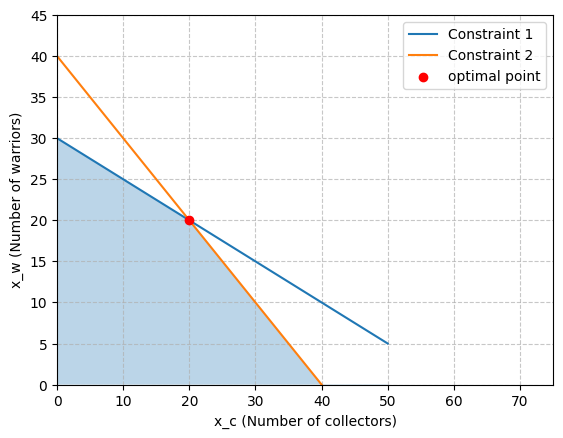

In [207]:
# Coeficients (weigths) of the objective function (denied for maximization)
fourth_scenario_coeficients = [-0.3,-0.5]

fourth_n_collectors, fourth_n_warriors = linear_programming_solutions(fourth_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {fourth_n_collectors} collectors and {fourth_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=fourth_n_collectors,y_coord=fourth_n_warriors)

### Define the weights function

We defined the problem with their specific constraints to modeling a linear programming (LP) problem using the simplex algorithm to solve.
As we discuted on the previous cells, the function to maximize for the LP problem is:

$max($ $\theta_{1} * x_c + \theta_{2} * x_w )$

subject to:

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq b$

3. $x_c + x_w \leq 50 - C_u$

Where $\theta_{1}$ and $\theta_{2}$ define the importance of produce each type of unit. However that weights aren't trivally, we must to formulate a function
that compute the values of the weights considering a lot of vairables in the game. In the section below, we propose that function.

To achieve this objective, we defined a class named GameOptimizer, an abstract class that have childs which produce an optimizer for each type of difficulty.

Out first task is to define the main class which have an abstract method of `get_weights()`, and a own method named `optimize()` and `linear_programming_solutions()`.

**Summary about the methods**
- `optimize()` use the `get_weights()` abstract method from class inherits for each difficulty **(compute the weight of produce collectors or warriors depends on some factors)**. Finally apply the `linear_programming_solutions()` to solve the linear programming problem, with previous defined boudarys, variables, etc.

DEBO DEFINIR QUE NO GASTE EL ORO A LO LOCO

In [208]:
from inspect import currentframe
from abc import ABC, abstractmethod
from scipy.optimize import linprog
import random

# MAIN class: have get_weights and optimize methods.
class GameOptiimizer(ABC):
  """
  DEFINE: the different constants for the system
  - The cost of collectors
  - The cost of warriors
  - The maximum number of units by player (1)
  - The maximum number of collectors and warriors respect to (1)
  """
  COST_COLLECTORS = 100
  COST_WARRIORS = 200
  MAX_UNITS = 50
  MAX_NUMBER_COLLECTORS = MAX_UNITS * 0.4
  MAX_NUMBER_WARRIORS = MAX_UNITS * 0.6

  # Constraint 1: cost_a * xc + cost_b * xw <= budget
  # Constraint 2: xc + xw <= 50
  A_matrix_constraints = [
      [COST_COLLECTORS, COST_WARRIORS],
      [1,1]
  ]


  def __init__(self, boundary=300, current_collectors=0, current_warriors=0):
    # DEFINE: more constants for the problem
    self.BOUNDARY = boundary
    self.CURRENT_COLLECTORS = current_collectors
    self.CURRENT_WARRIORS = current_warriors
    self.CURRENT_UNITS = self.CURRENT_COLLECTORS + self.CURRENT_WARRIORS
    self.b_matrix_boundary = [
      self.BOUNDARY,
      self.MAX_UNITS - self.CURRENT_UNITS
    ]
    self.bounds = [(0,None), (0,None)]  # Bounds for the variables 
  

  @abstractmethod
  def get_weights(self) -> tuple[float,float]:
    pass

  
  def optimize(self):
    weight_collector, weight_warrior = self.get_weights()
    # Coeficients (weigths) of the objective function (denied for maximization)
    coeficients = [-weight_collector,-weight_warrior]
    print("The weights for the problem are: ", coeficients)
    n_collectors, n_warriors = self.linear_programming_solutions(coeficients, self.A_matrix_constraints, self.b_matrix_boundary, self.bounds)
    print(f"You have to produce {n_collectors} collectors and {n_warriors} warriors.")
    plot_solution_space(optimal_point=True,x_coord=n_collectors,y_coord=n_warriors)
    
  
  def linear_programming_solutions(self, coef, A_ub, b_ub, bounds):
    results = linprog(coef, A_ub=A_ub, b_ub=b_ub, bounds=bounds)
    if results.success == False:
      return (0.0,0.0)
    return results.x[0], results.x[1]

#### `EasyOptimizer` **Class**
Simple implementation to compute the weights of collectors and warriors. The procedure selects a random number between **0 and 1** using `random` library of python.

In [209]:
# EASY optimizer class inhertis from GameOptimize class to modify own get_weights method
class EasyOptimizer(GameOptiimizer):
  def get_weights(self) -> tuple[float, float]:
    w_collector = random.random()
    w_warrior = random.random()
    return (w_collector, w_warrior)

The weights for the problem are:  [-0.1038381978120696, -0.3059402421352865]
You have to produce 0.0 collectors and 1.5 warriors.


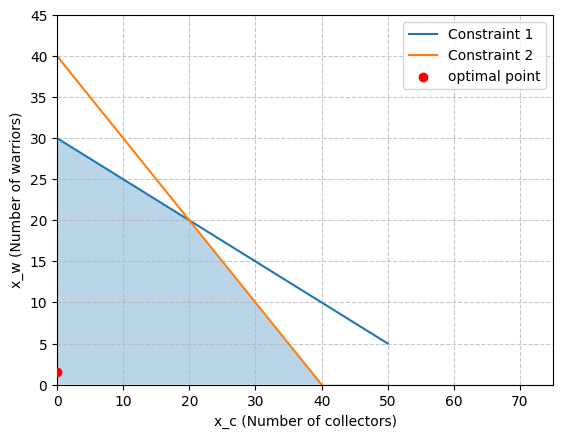

In [210]:
# Test easy bot with certain number of collectors and warriors
Easy_Bot = EasyOptimizer(current_collectors=40, current_warriors=0)
Easy_Bot.optimize()

#### `MediumOptimizer` **Class**
More elaborate implementation to compute the weights of collectors and warriors. The procedure follows:
1. `collector_weights()` method, divide the maximum number of collectors into three slides. Depend on the slide, a certain weight is assigned. While the player have less collectors, the weight is stronger, and it keeps going down until reach the maxium number of collectors.
2. `warriors_weights()` method, also divide in slides with the number of collectors to carry out a inverse process. While the player have more collectors the weight of produce warriors is strong.

In [211]:
# MEDIUM optimizer class inhertis from GameOptimize class to modify own get_weights method
class MediumOptimizer(GameOptiimizer):
  
  def get_weights(self) -> tuple[float, float]:
    w_collector = self.collector_weights(self.CURRENT_COLLECTORS)
    w_warrior = self.warrior_weights(self.CURRENT_WARRIORS, self.CURRENT_COLLECTORS)
    return w_collector, w_warrior


  def collector_weights(self, current_collectors: int) -> float:
    """
    DIVIDE the maximum number of collectors into 3 slides (25%, 50%, 75%)
    depending on the position of current number of collectors, an if statement'll be
    execute.
    """
    weight = 0.0
    max_number = self.MAX_NUMBER_COLLECTORS
    if current_collectors < max_number:
      slice_1 = max_number * 0.30
      slice_2 = max_number * 0.5
      slice_3 = max_number * 0.75

      # BETWEEN (0 and 6)
      if 0 <= current_collectors <= slice_1:
          weight = 1.0
          return weight
      # BETWEEN (7 and 10)
      elif slice_1 < current_collectors <= slice_2:
          weight = 0.6
          return weight
      # BETWEEN (11 and 15)
      elif slice_2 < current_collectors <= slice_3:
          weight = 0.4
          return weight
      # BETWEEN (16 and 19)
      elif slice_3 < current_collectors < max_number:
          weight = 0.2
          return weight
    return weight


  def warrior_weights(self, current_warriors: int, current_collectors: int) -> float:
    """
    CONSIDER the slides of collectors, and in place of decrease the weight of collectors over the time
    the weight of warriors increase their weight.
    """
    max_collectors = self.MAX_NUMBER_COLLECTORS
    max_warriors = self.MAX_NUMBER_WARRIORS
    weight = 0.0

    if current_warriors < max_warriors:
      slice_1_collectors = max_collectors * 0.3
      slice_2_collectors = max_collectors * 0.5
      slice_3_collectors = max_collectors * 0.75

      # BETWEEN (0 and 6) on collectors
      if 0 <= current_collectors <= slice_1_collectors:
        return weight
      # BETWEEN (7 and 10) on collectors
      elif slice_1_collectors < current_collectors <= slice_2_collectors:
        weight = 0.4
        return weight
      # BETWEEN (11 and 15) on collectors
      elif slice_2_collectors < current_collectors <= slice_3_collectors:
        weight = 0.6
        return weight
      # BETWEEN (16 and 20) on collectors
      elif slice_3_collectors < current_collectors < max_collectors:
        weight = 0.8
        return weight
      # WHEN user collectors have 20 collectors
      elif current_collectors == max_collectors:
        weight = 1.0
        return weight
    
    return weight

The weights for the problem are:  [-0.6, -0.0]
You have to produce 3.0 collectors and 0.0 warriors.


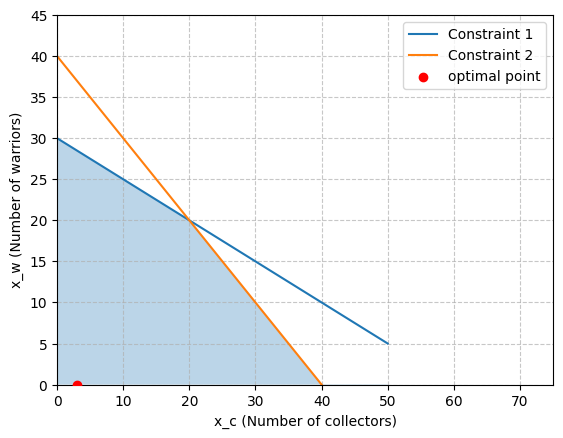

In [212]:
# Test medium bot with certain number of collectors and warriors
Medium_Bot = MediumOptimizer(current_collectors=10, current_warriors=32)
Medium_Bot.optimize()

#### `HardOptimizer` **Class**
Complex implementation to compute the weights of collectors and warriors. The procedure follows:

In [213]:
# HARD optimizer class inhertis from GameOptimize class to modify own get_weights method
class HardOptimizer(GameOptiimizer):

  def get_weights(self) -> tuple[float, float]:
      """TODO: Consider the following requeriments:
              1. The number of mines in possesion of user
              2. The collectors time takes to travel since the base up to mine
              3. The initial quntity on the mine
      """
      pass